Loaded bbox rows for 200 image/segment pairs from /Users/zd3504phd/Desktop/XAIV/results/cifar100/cifar100_segmented.csv
Loaded 200 complete triplets from /Users/zd3504phd/Desktop/XAIV/benchmarks/cifar100_all/debug_vis


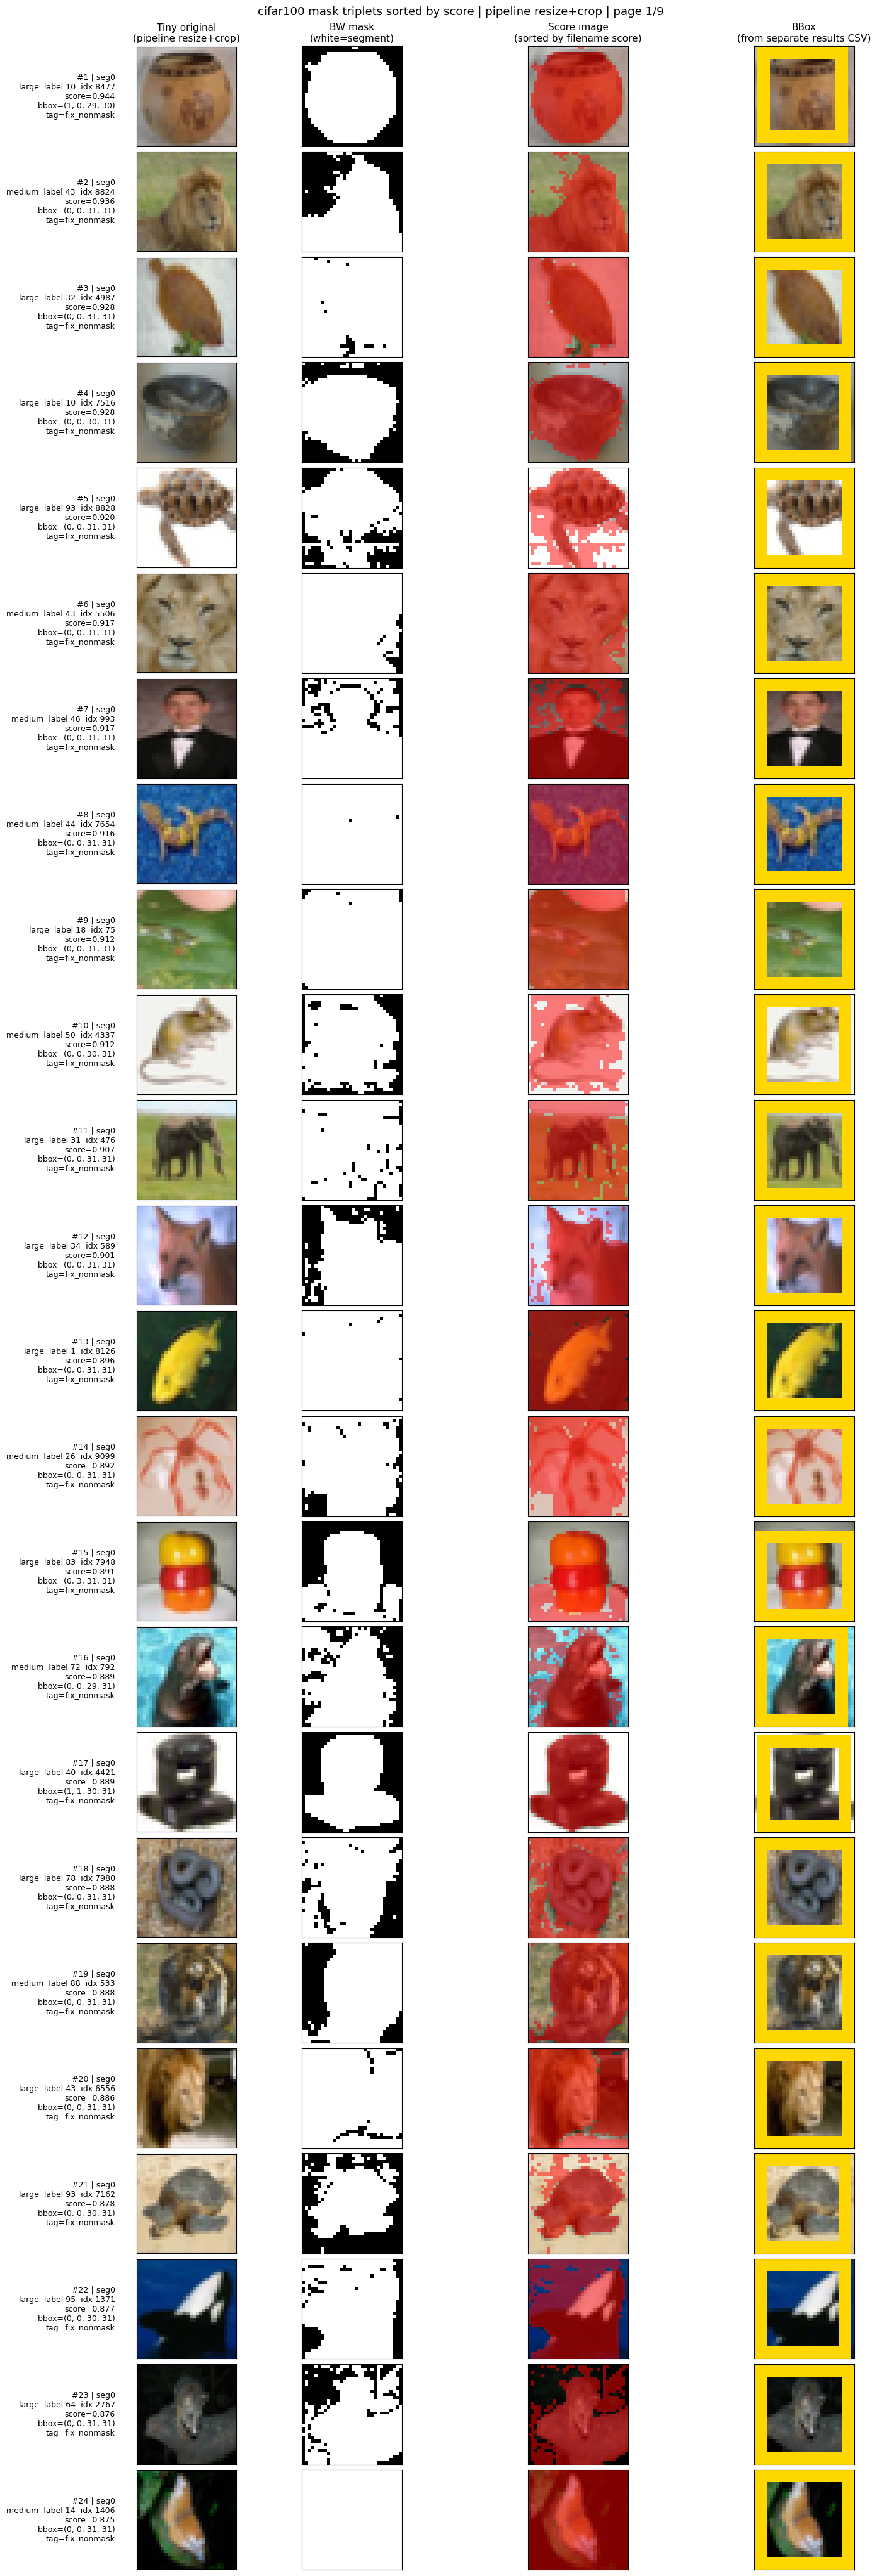

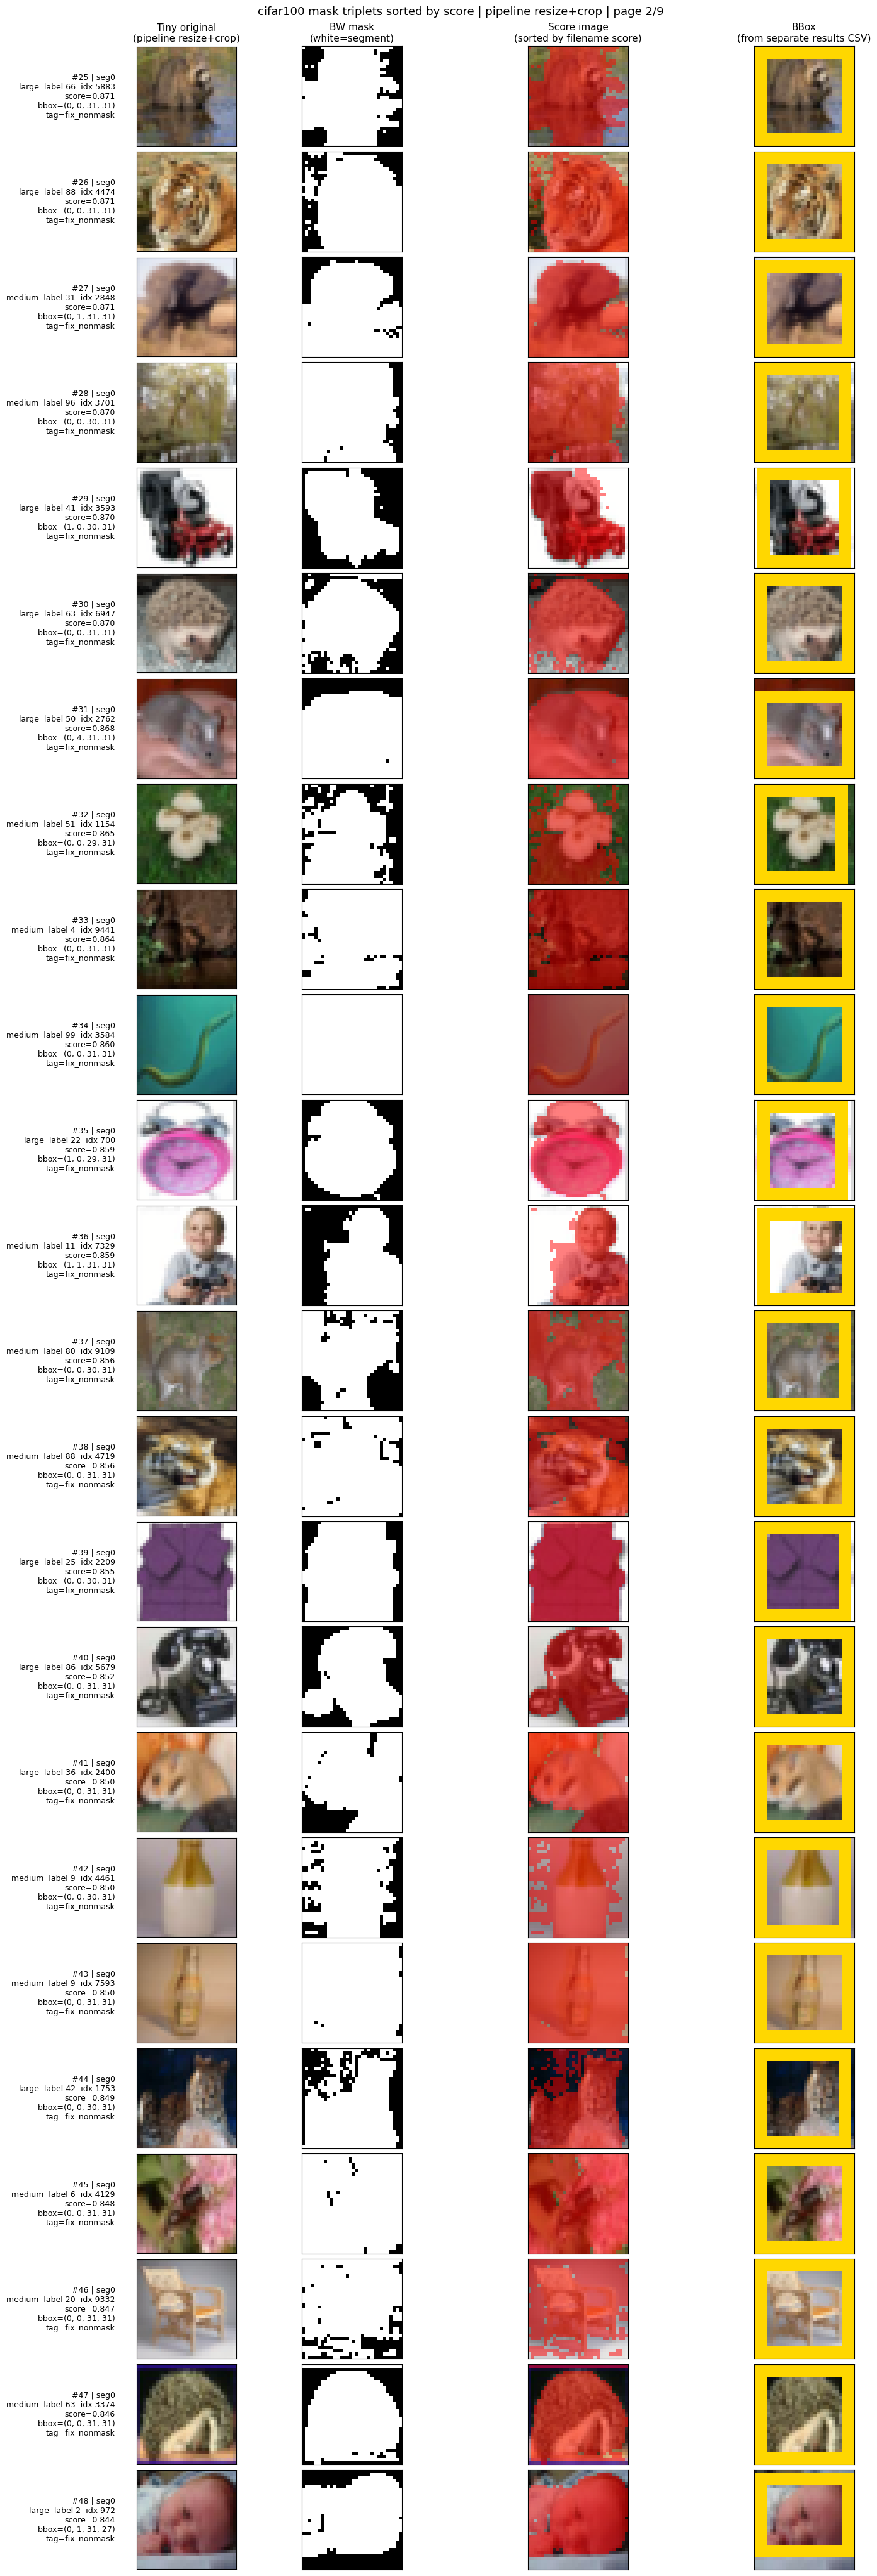

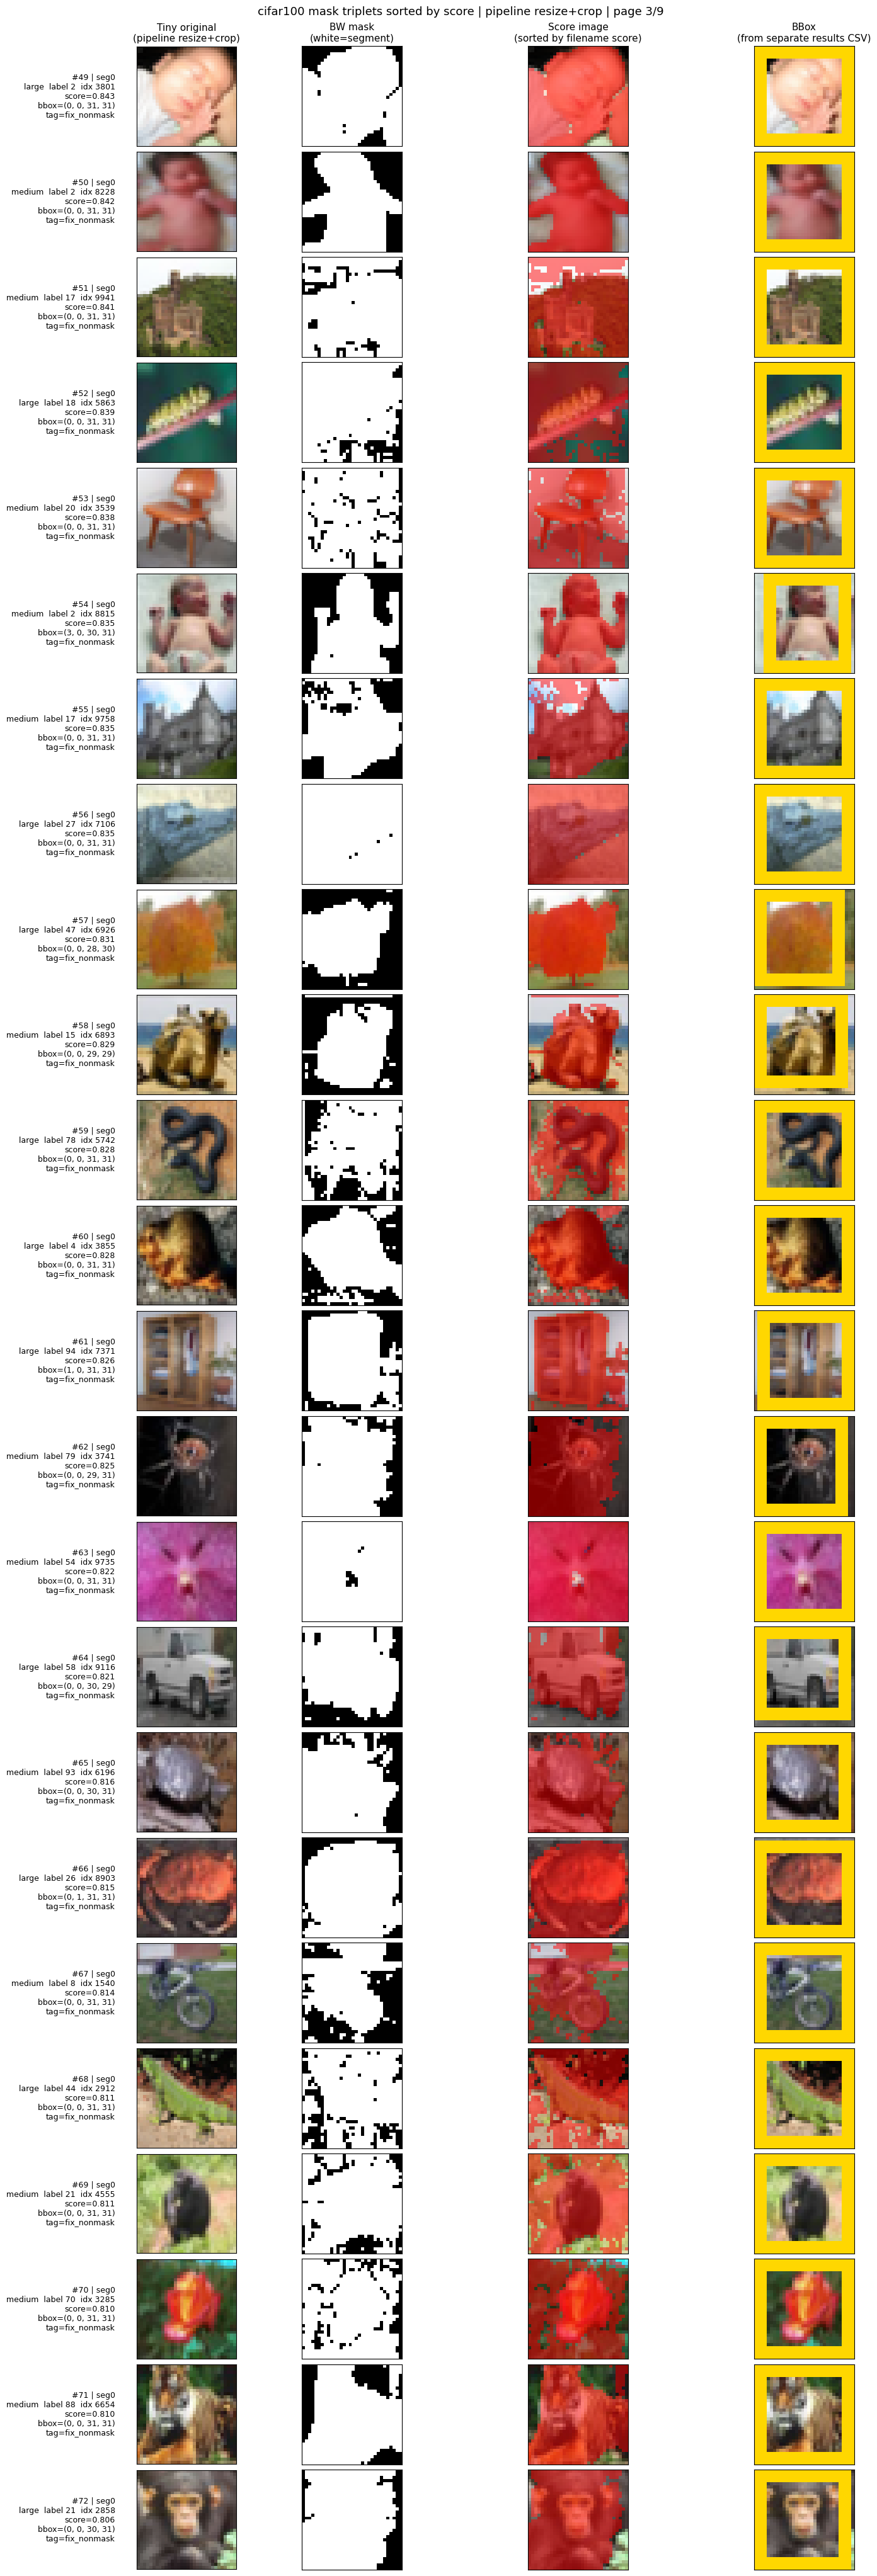

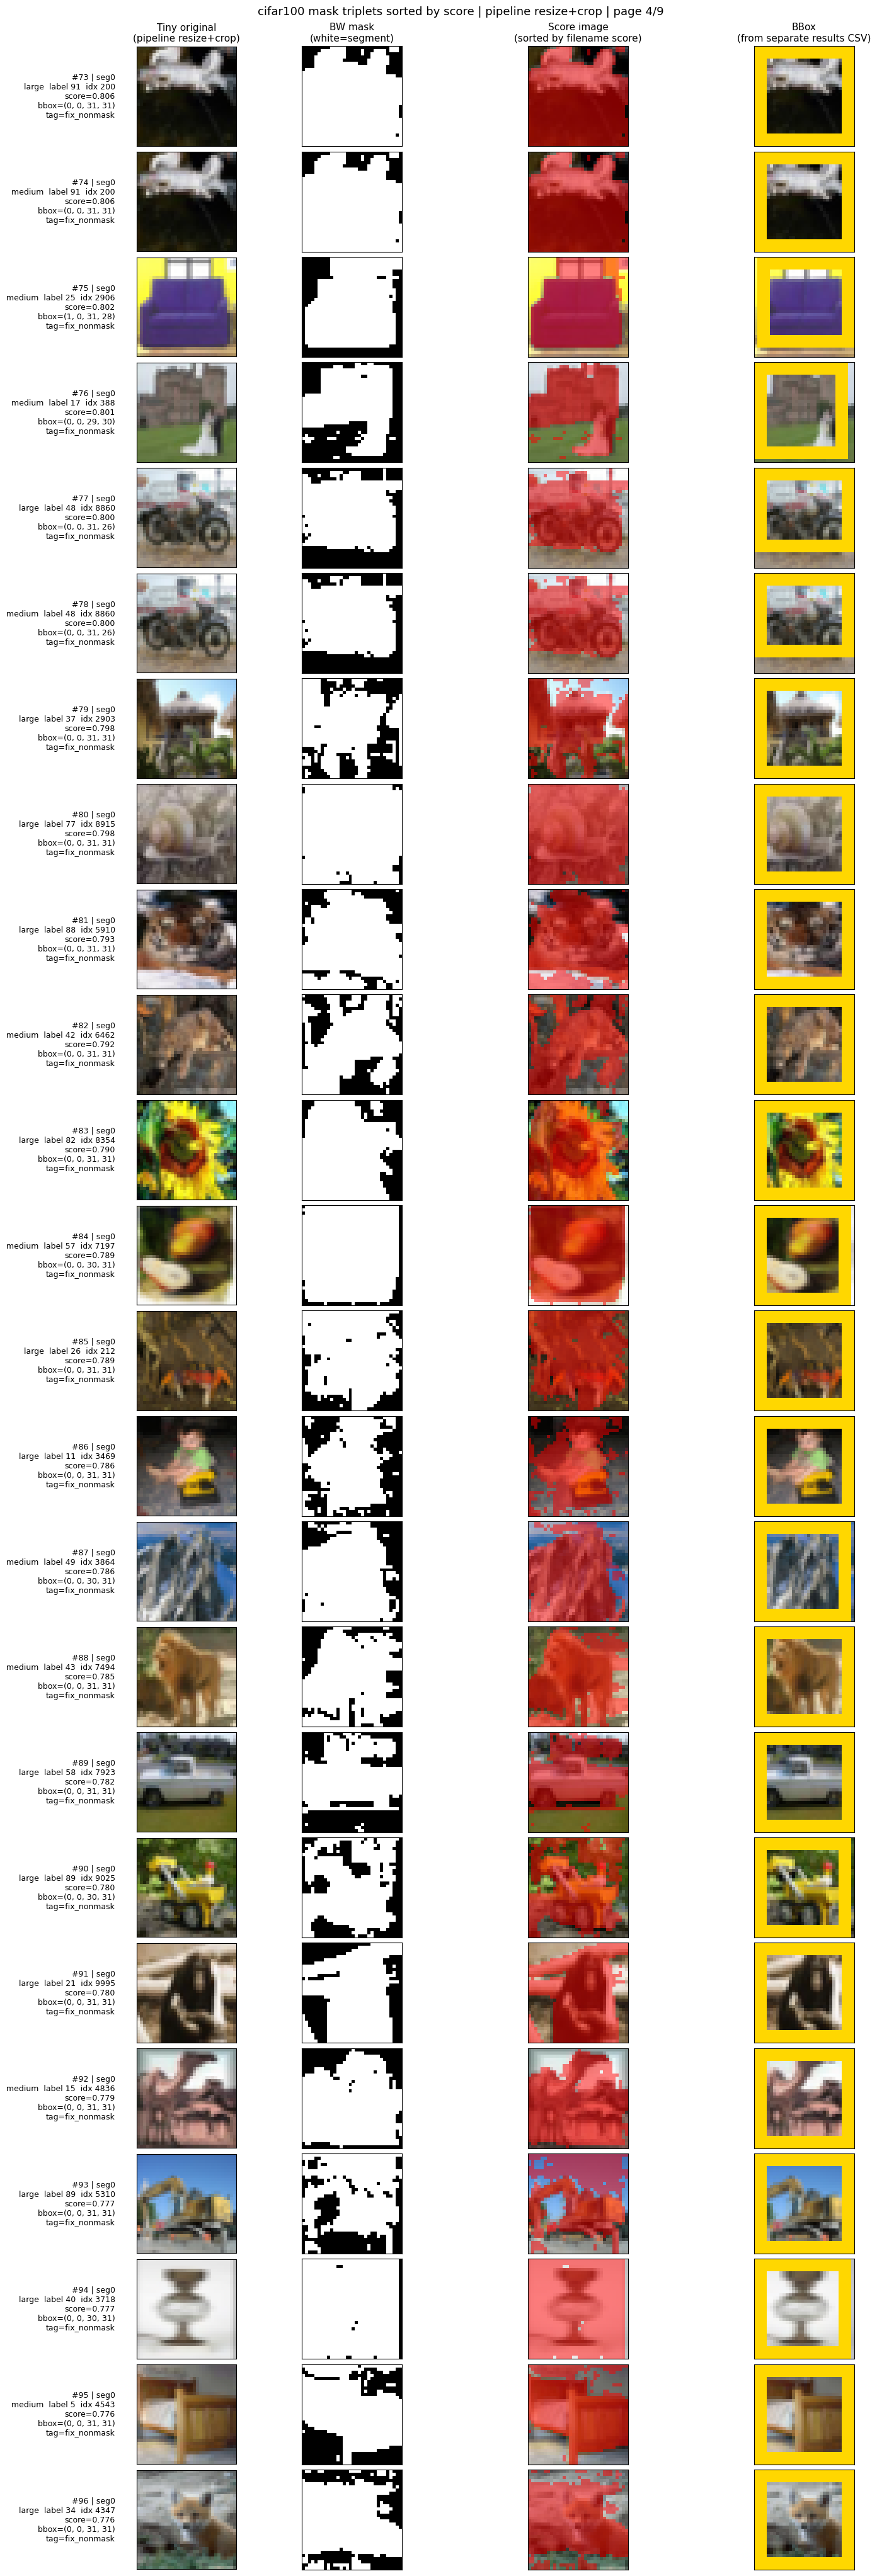

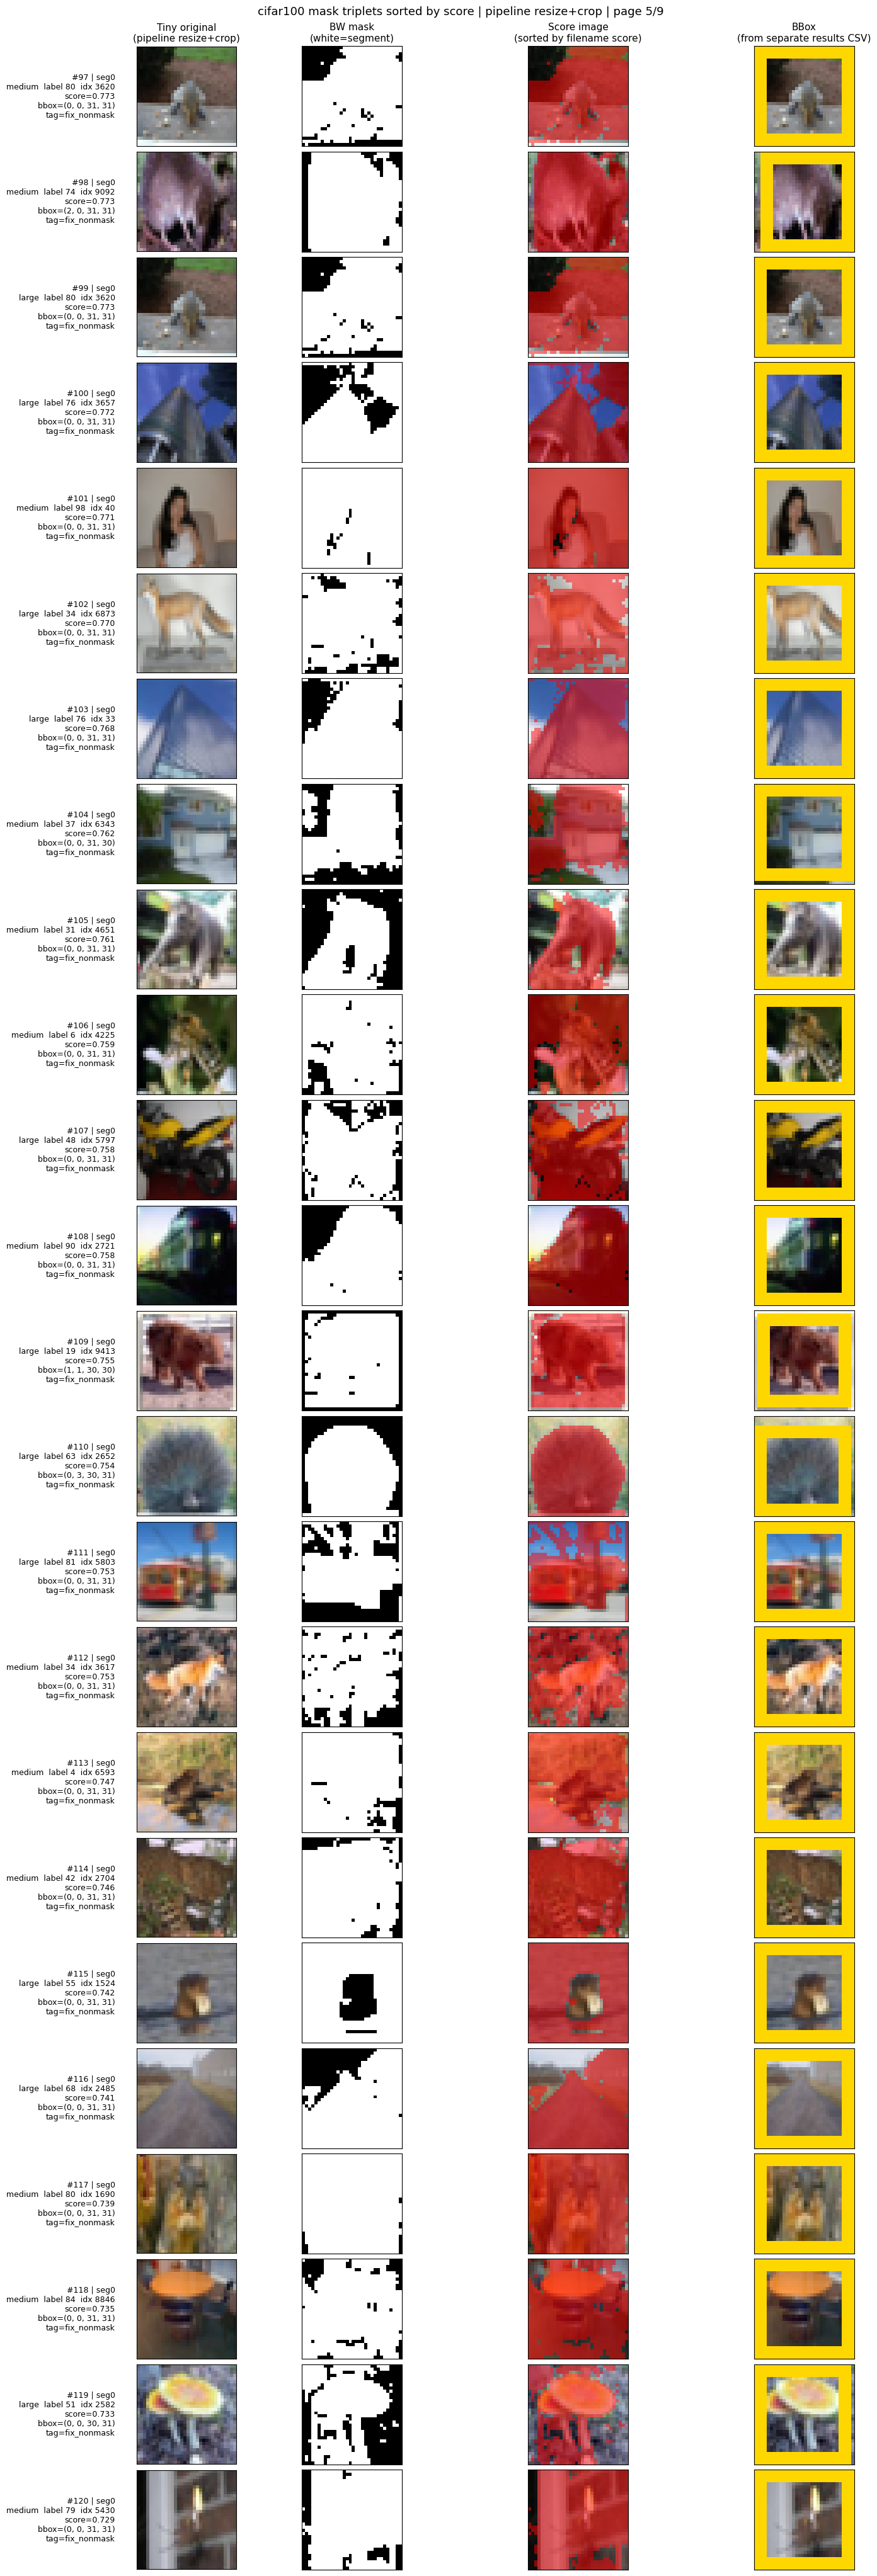

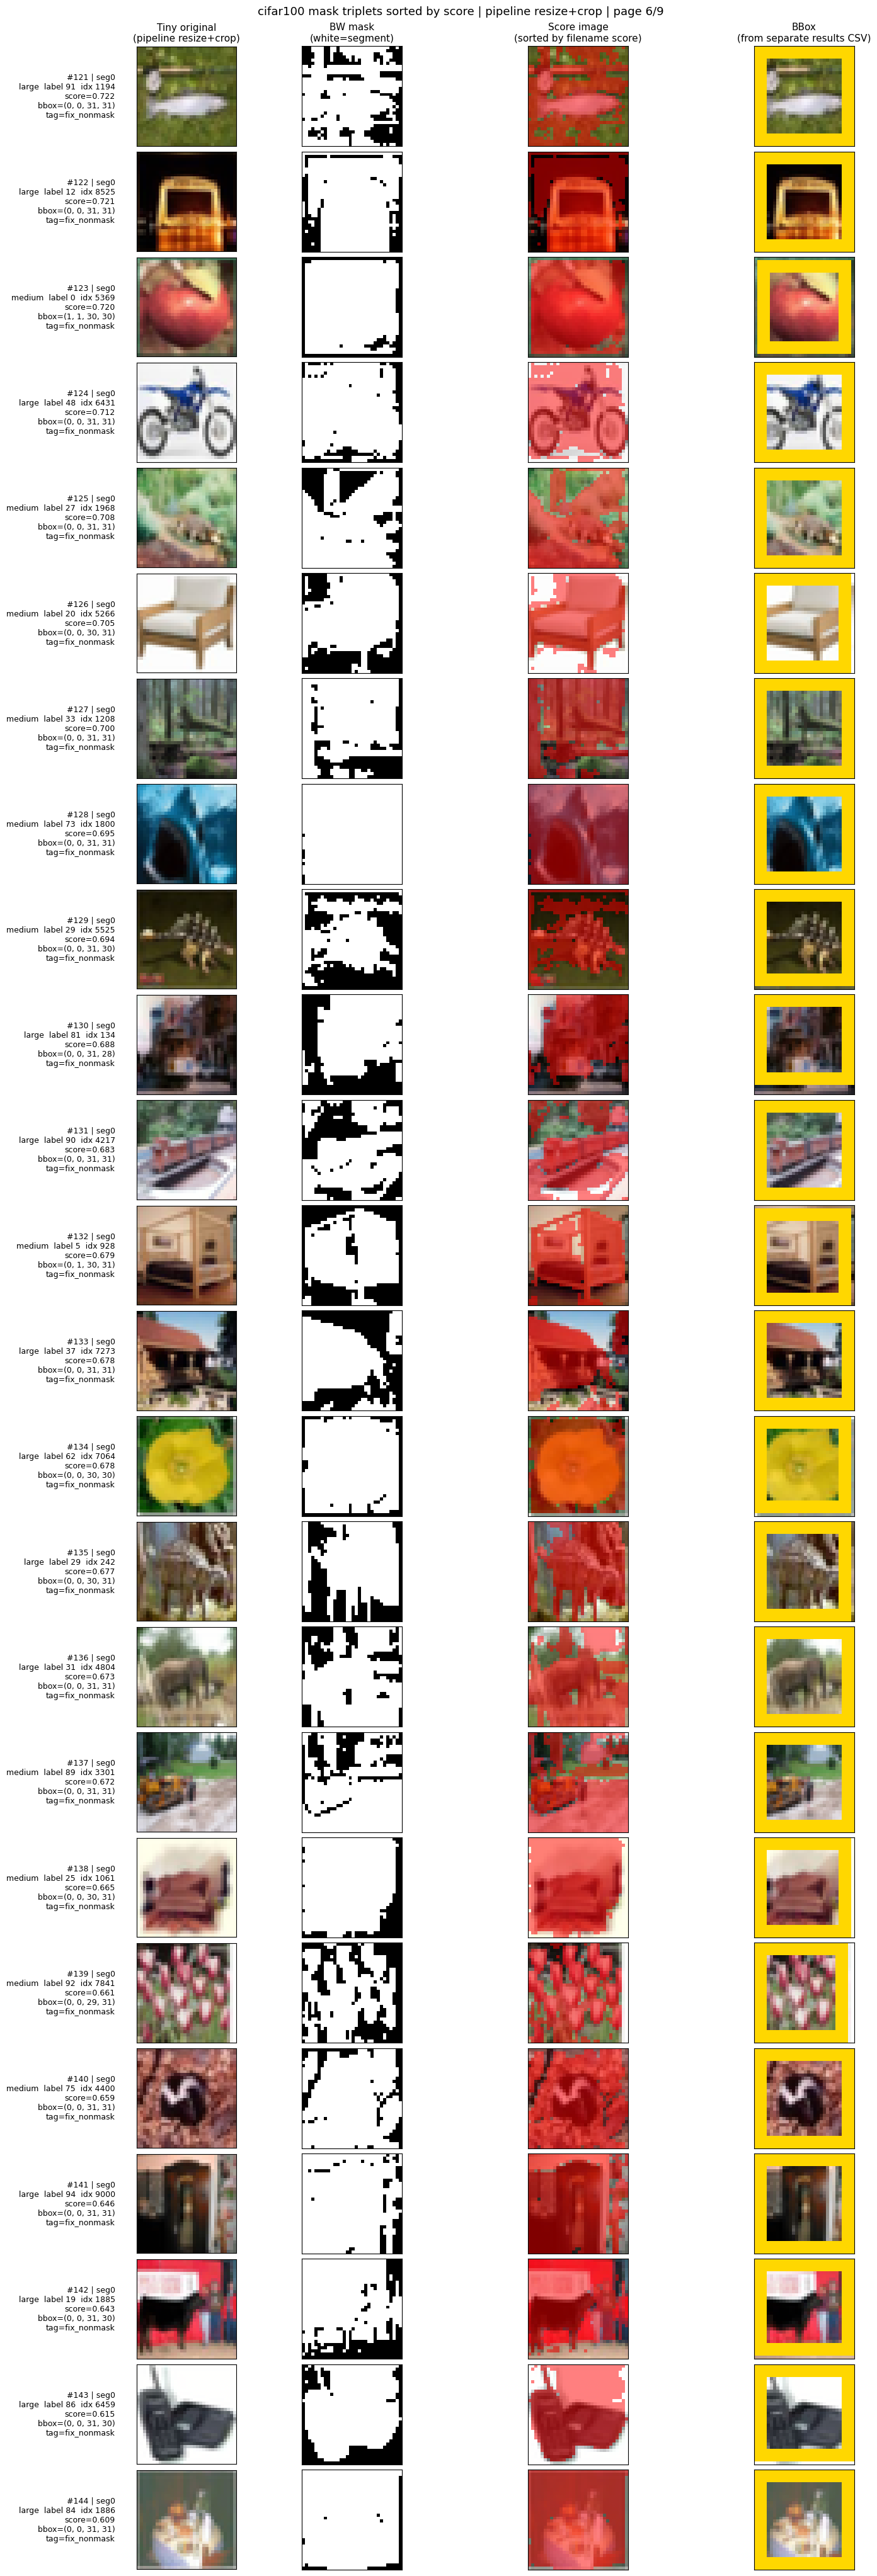

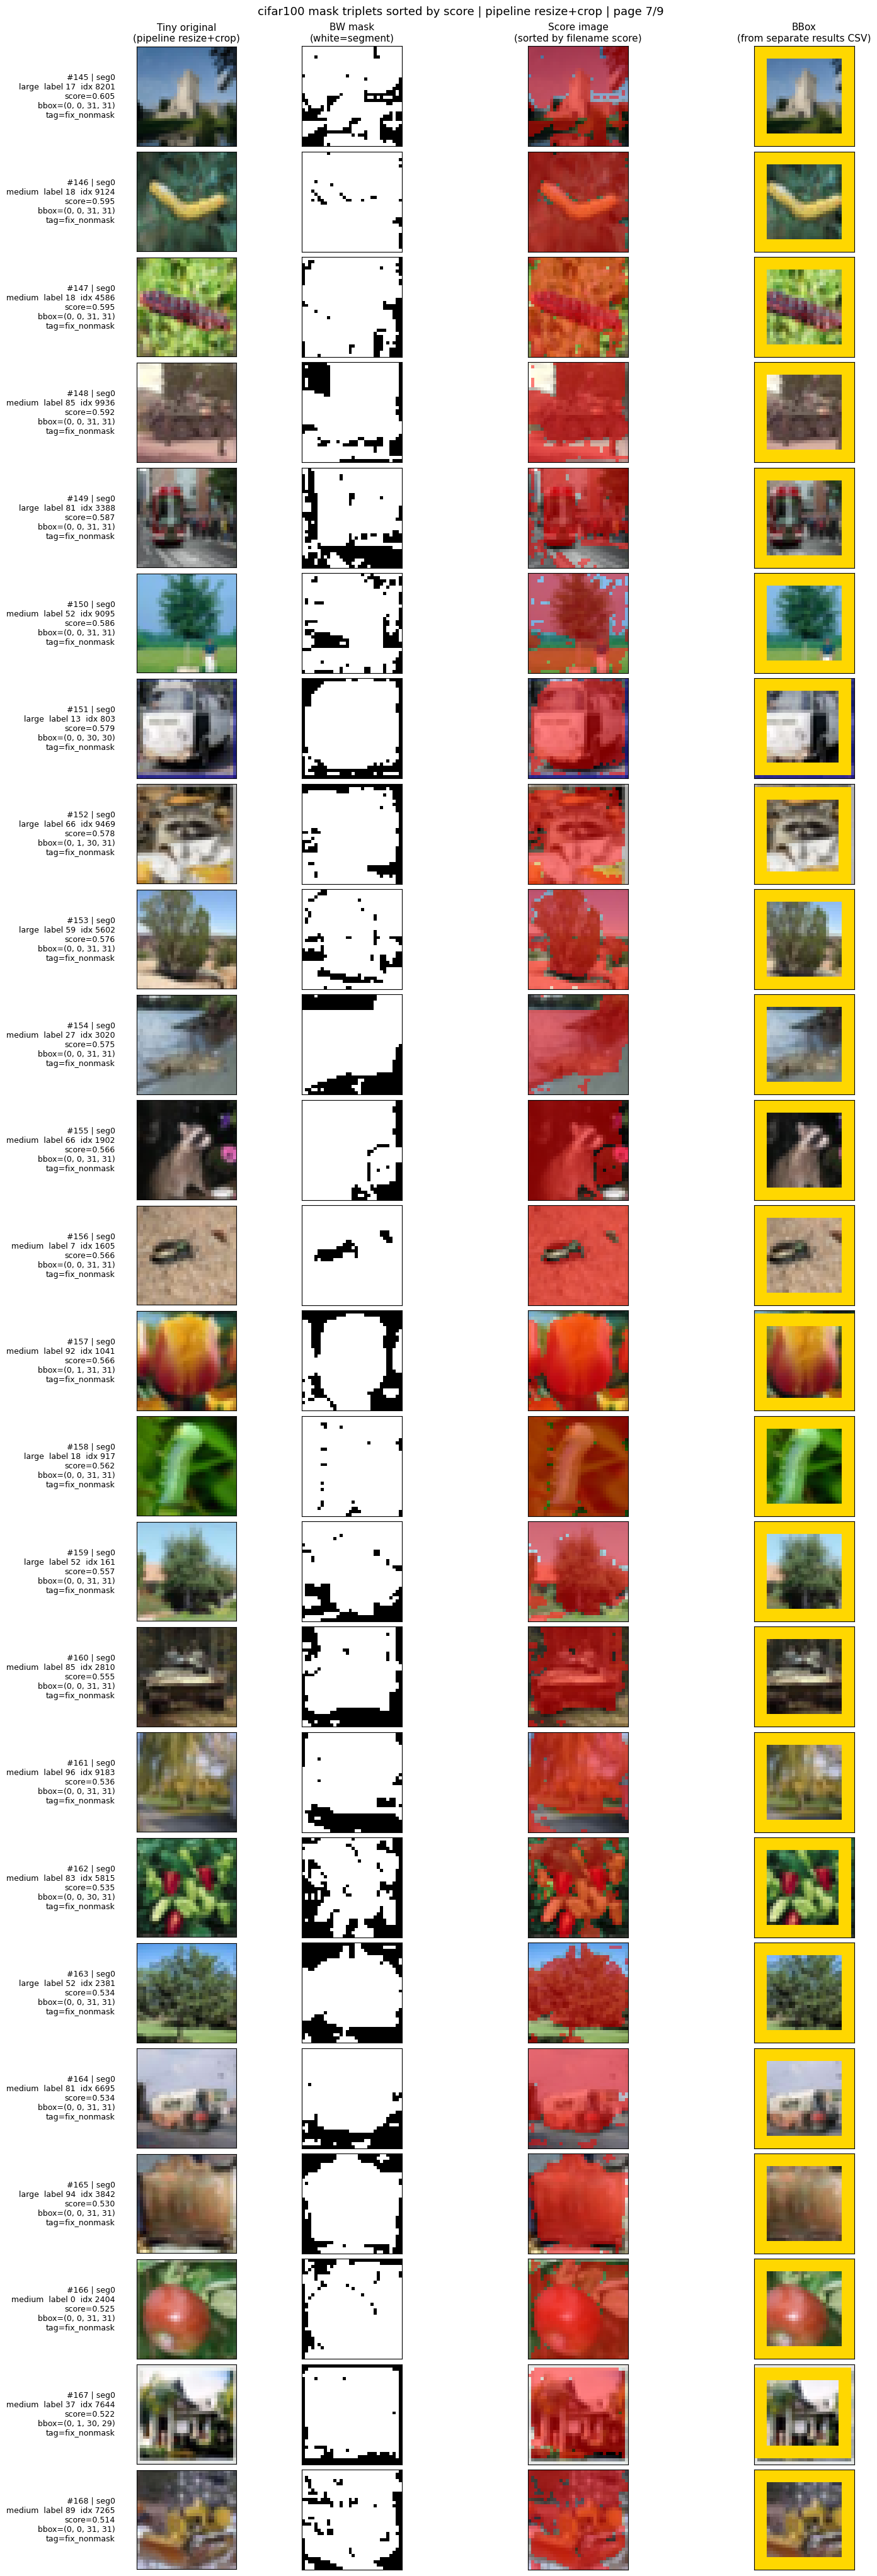

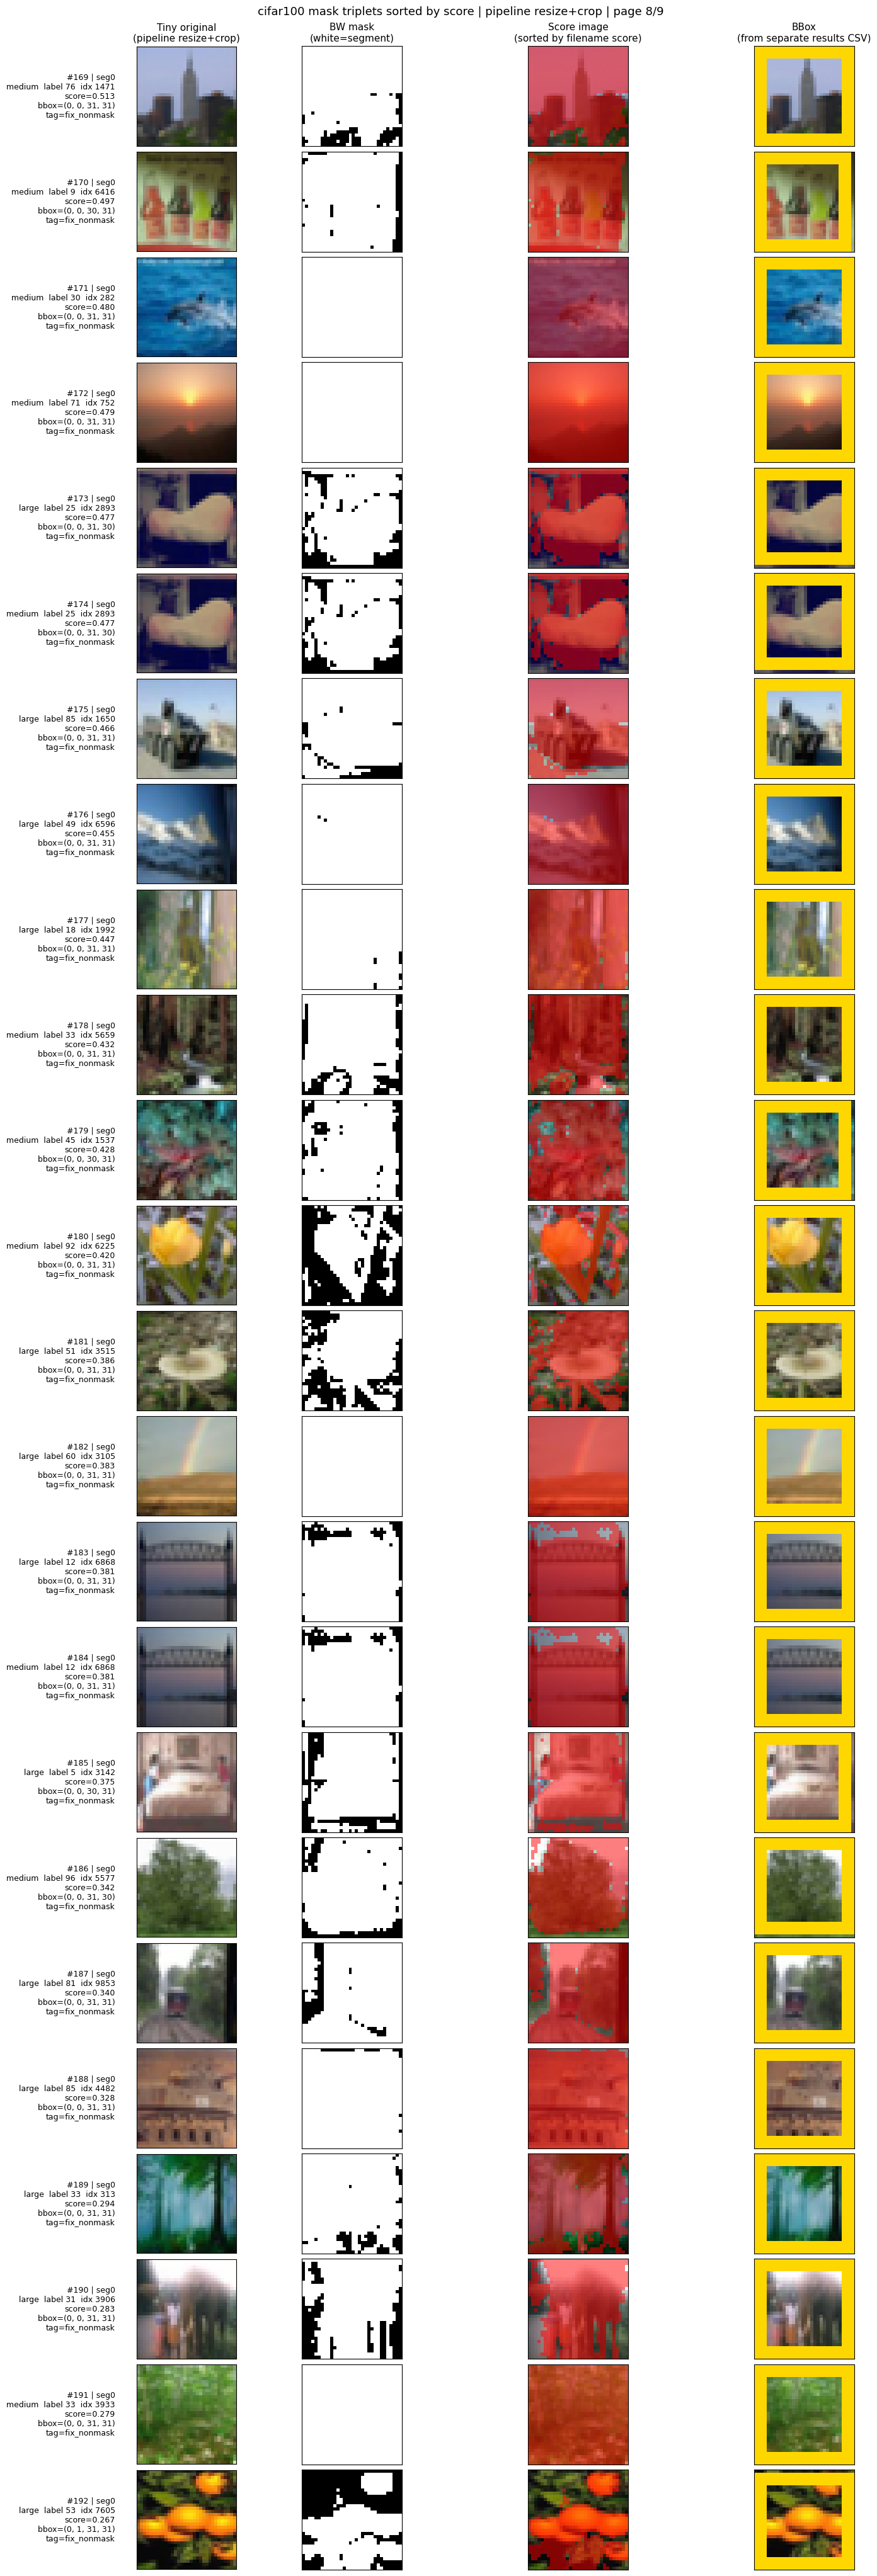

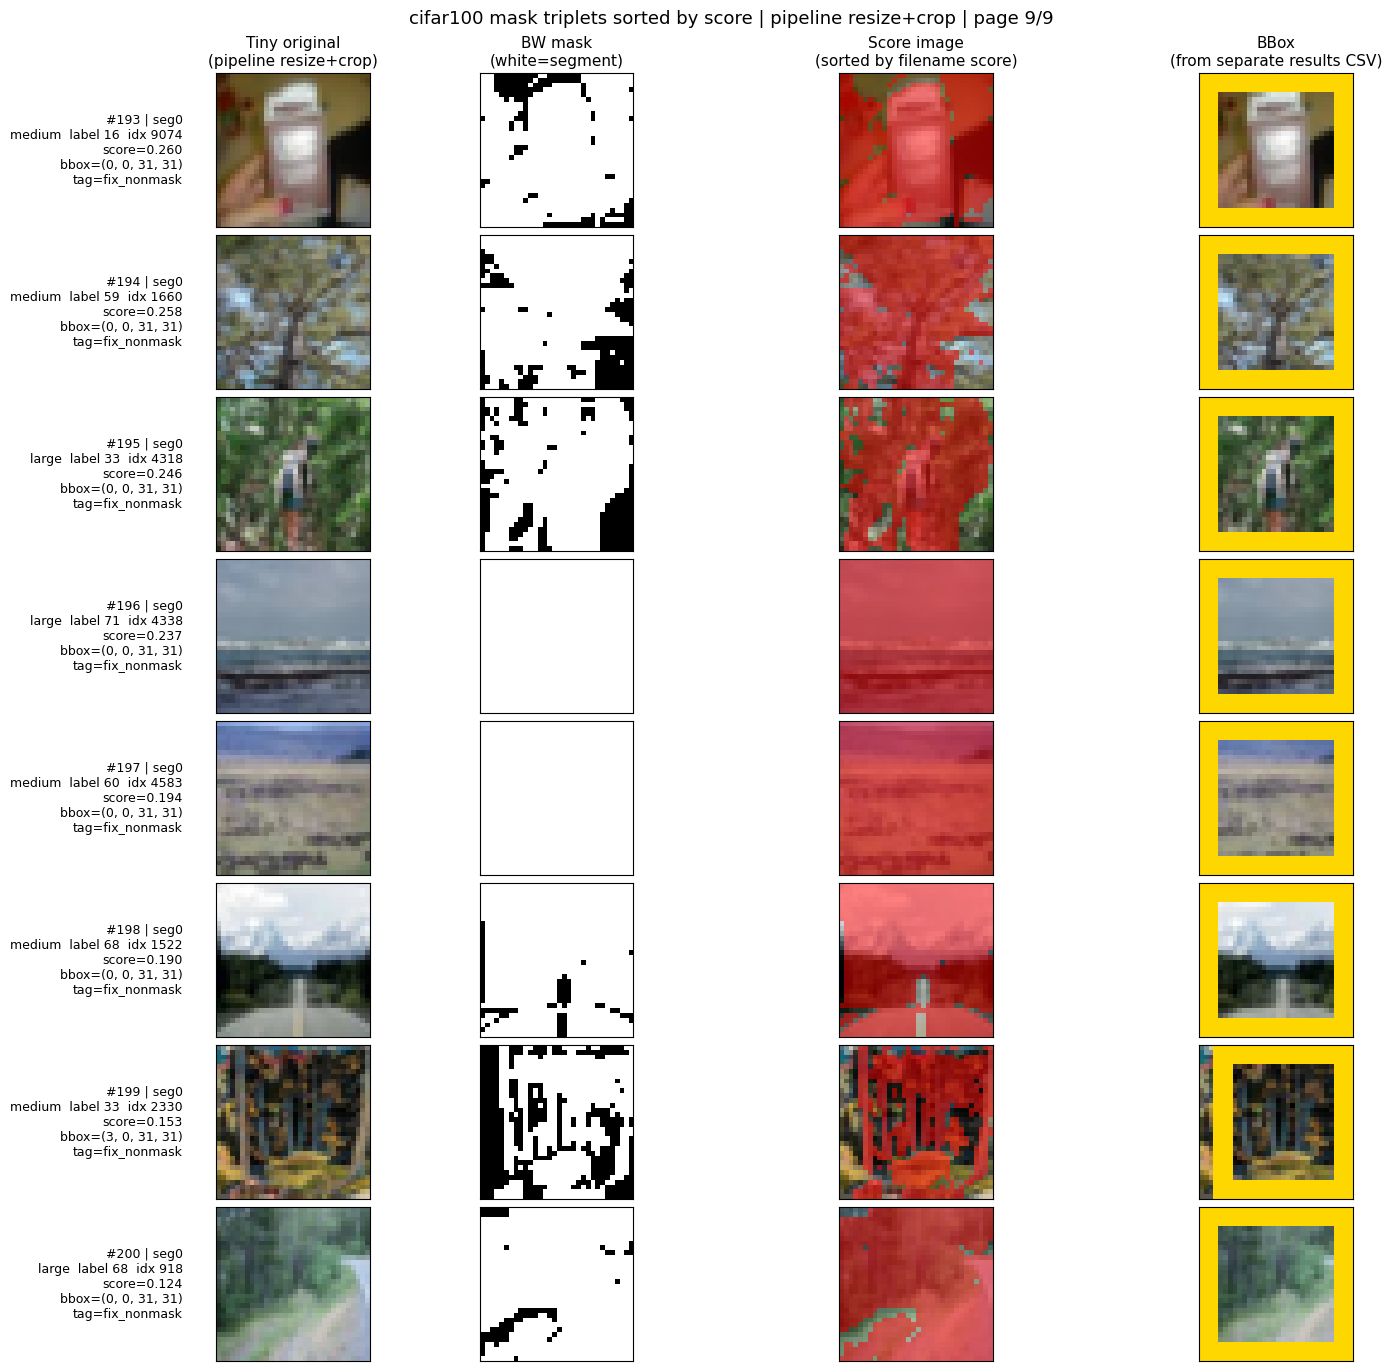

Saved PDF to /Users/zd3504phd/Desktop/XAIV/analysis/imagenet_mask_vis/cifar100_mask_vis.pdf


In [5]:
import ast
import csv
import os
from math import ceil
from pathlib import Path
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image, ImageDraw

# =========================
# Paths
# =========================
IMAGE_DIR = Path("/Users/zd3504phd/Desktop/XAIV/benchmarks/cifar100_all/debug_vis")

# This is now the CSV that contains bbox values like:
# image,tag,segment_index,...,bbox,...
BBOX_CSV_PATH = Path("/Users/zd3504phd/Desktop/XAIV/results/cifar100/cifar100_segmented.csv")

OUTPUT_PDF = Path("/Users/zd3504phd/Desktop/XAIV/analysis/imagenet_mask_vis/cifar100_mask_vis.pdf")

ITEMS_PER_PAGE = 24
DISPLAY_SIZE = 32
SORT_DESCENDING = True

RESAMPLING = Image.Resampling if hasattr(Image, "Resampling") else Image

SCORE_PATTERN = re.compile(
    r"^(?P<stem>.+?)_seg(?P<segment_index>\d+)_score_(?P<score>\d+(?:\.\d+)?)\.png$"
)


def pipeline_resize_center_crop(img: Image.Image, interpolation) -> Image.Image:
    width, height = img.size
    if width <= 0 or height <= 0:
        raise ValueError(f"Invalid image size: {(width, height)}")

    if width < height:
        new_width = DISPLAY_SIZE
        new_height = round(height * DISPLAY_SIZE / width)
    else:
        new_height = DISPLAY_SIZE
        new_width = round(width * DISPLAY_SIZE / height)

    img = img.resize((new_width, new_height), interpolation)
    left = max(0, (new_width - DISPLAY_SIZE) // 2)
    top = max(0, (new_height - DISPLAY_SIZE) // 2)
    return img.crop((left, top, left + DISPLAY_SIZE, top + DISPLAY_SIZE))


def preprocess_image(path: Path, mode: str, interpolation):
    with Image.open(path) as img:
        img = img.convert(mode)
        img = pipeline_resize_center_crop(img, interpolation)
        return np.asarray(img)


def parse_bbox(bbox_text):
    """
    Parse bbox strings like:
    "[0, 0, 30, 31]"
    """
    if bbox_text is None:
        return None

    bbox_text = str(bbox_text).strip()
    if bbox_text == "":
        return None

    try:
        bbox = ast.literal_eval(bbox_text)
        if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
            return tuple(int(v) for v in bbox)
    except Exception:
        pass

    return None


def load_bbox_lookup_from_results_csv(csv_path: Path):
    """
    Load bbox values from a separate results CSV.

    Expected columns include at least:
      - image
      - tag
      - segment_index
      - bbox

    Example key:
      ('resnet_large__label_10__idx_7516', 0)

    Preference rule:
      if both fix_mask and fix_nonmask exist for the same (image, segment_index),
      prefer fix_nonmask, matching your previous behavior.
    """
    bbox_lookup = {}

    if not csv_path.exists():
        print(f"No bbox CSV found at {csv_path}")
        return bbox_lookup

    with csv_path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            image = (row.get("image") or "").strip()
            tag = (row.get("tag") or "").strip()
            segment_index_text = (row.get("segment_index") or "").strip()
            bbox = parse_bbox(row.get("bbox"))

            # Skip rows without the needed fields
            if not image or segment_index_text == "":
                continue

            # Skip global rows
            if tag == "global":
                continue

            # Some rows may have empty bbox
            if bbox is None:
                continue

            try:
                segment_index = int(segment_index_text)
            except ValueError:
                continue

            key = (image, segment_index)
            candidate = {
                "bbox": bbox,
                "tag": tag if tag else "unknown",
            }

            existing = bbox_lookup.get(key)

            # Same preference as your old code:
            # overwrite existing if new row is fix_nonmask
            if existing is None or candidate["tag"] == "fix_nonmask":
                bbox_lookup[key] = candidate

    print(f"Loaded bbox rows for {len(bbox_lookup)} image/segment pairs from {csv_path}")
    return bbox_lookup


def collect_triplets(image_dir: Path, bbox_lookup):
    if not image_dir.exists():
        raise FileNotFoundError(image_dir)

    triplets = []
    missing_files = []

    for score_path in image_dir.glob("*_seg*_score_*.png"):
        match = SCORE_PATTERN.match(score_path.name)
        if match is None:
            continue

        stem = match.group("stem")
        segment_index = int(match.group("segment_index"))
        original_path = image_dir / f"{stem}_original.png"
        mask_path = image_dir / f"{stem}_seg{segment_index}_mask_bw.png"

        if not original_path.exists() or not mask_path.exists():
            missing_files.append(score_path.name)
            continue

        bbox_entry = bbox_lookup.get((stem, segment_index), {})

        triplets.append(
            {
                "stem": stem,
                "segment_index": segment_index,
                "label": stem.split("_", 1)[1].replace("_", " ") if "_" in stem else stem,
                "score": float(match.group("score")),
                "original_path": original_path,
                "mask_path": mask_path,
                "score_path": score_path,
                "bbox": bbox_entry.get("bbox"),
                "bbox_tag": bbox_entry.get("tag"),
            }
        )

    triplets.sort(key=lambda item: item["score"], reverse=SORT_DESCENDING)

    print(f"Loaded {len(triplets)} complete triplets from {image_dir}")
    if missing_files:
        print(f"Skipped {len(missing_files)} incomplete triplets")

    return triplets


def draw_bbox_panel(original_rgb: np.ndarray, bbox):
    bbox_img = Image.fromarray(original_rgb.copy())
    drawer = ImageDraw.Draw(bbox_img)

    if bbox is not None:
        # bbox format: [x1, y1, x2, y2]
        drawer.rectangle(bbox, outline=(255, 215, 0), width=4)
    else:
        drawer.text((8, 8), "bbox missing", fill=(255, 0, 0))

    return np.asarray(bbox_img)


def show_triplets(triplets, output_pdf: Path, items_per_page=24):
    if not triplets:
        raise ValueError(f"No triplets found in {IMAGE_DIR}")
    if items_per_page <= 0:
        raise ValueError("items_per_page must be positive")

    output_pdf.parent.mkdir(parents=True, exist_ok=True)
    page_count = ceil(len(triplets) / items_per_page)

    column_titles = (
        "Tiny original\n(pipeline resize+crop)",
        "BW mask\n(white=segment)",
        "Score image\n(sorted by filename score)",
        "BBox\n(from separate results CSV)",
    )

    with PdfPages(output_pdf) as pdf:
        for page_idx in range(page_count):
            start = page_idx * items_per_page
            page = triplets[start : start + items_per_page]

            fig, axes = plt.subplots(
                nrows=len(page),
                ncols=4,
                figsize=(14.5, max(2.8, 1.7 * len(page))),
                width_ratios=(0.45, 1.0, 1.0, 1.0),
                squeeze=False,
                constrained_layout=True,
            )

            for row_idx, item in enumerate(page):
                original = preprocess_image(
                    item["original_path"],
                    "RGB",
                    RESAMPLING.BILINEAR,
                )
                mask = preprocess_image(
                    item["mask_path"],
                    "L",
                    RESAMPLING.NEAREST,
                )
                score_image = preprocess_image(
                    item["score_path"],
                    "RGB",
                    RESAMPLING.BILINEAR,
                )
                bbox_image = draw_bbox_panel(original, item["bbox"])

                panels = (original, mask, score_image, bbox_image)

                for col_idx, (ax, panel) in enumerate(zip(axes[row_idx], panels)):
                    if col_idx == 1:
                        ax.imshow(panel, cmap="gray", vmin=0, vmax=255)
                    else:
                        ax.imshow(panel)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    if row_idx == 0:
                        ax.set_title(column_titles[col_idx], fontsize=11)

                bbox_text = item["bbox"] if item["bbox"] is not None else "missing"
                bbox_tag = item["bbox_tag"] if item["bbox_tag"] is not None else "N/A"

                row_label = (
                    f'#{start + row_idx + 1} | seg{item["segment_index"]}\n'
                    f'{item["label"]}\n'
                    f'score={item["score"]:.3f}\n'
                    f'bbox={bbox_text}\n'
                    f'tag={bbox_tag}'
                )

                axes[row_idx, 0].text(
                    -0.22,
                    0.5,
                    row_label,
                    transform=axes[row_idx, 0].transAxes,
                    ha="right",
                    va="center",
                    fontsize=9,
                )

            fig.suptitle(
                f"cifar100 mask triplets sorted by score | pipeline resize+crop | page {page_idx + 1}/{page_count}",
                fontsize=13,
            )
            pdf.savefig(fig, bbox_inches="tight")
            plt.show()
            plt.close(fig)

    print(f"Saved PDF to {output_pdf}")


bbox_lookup = load_bbox_lookup_from_results_csv(BBOX_CSV_PATH)
triplets = collect_triplets(IMAGE_DIR, bbox_lookup)
show_triplets(triplets, output_pdf=OUTPUT_PDF, items_per_page=ITEMS_PER_PAGE)